<a href="https://colab.research.google.com/github/Yash19815/iris-knn/blob/main/Iris_species.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [92]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

# print("Path to dataset files:", path)
df = pd.read_csv('/kaggle/input/iris/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


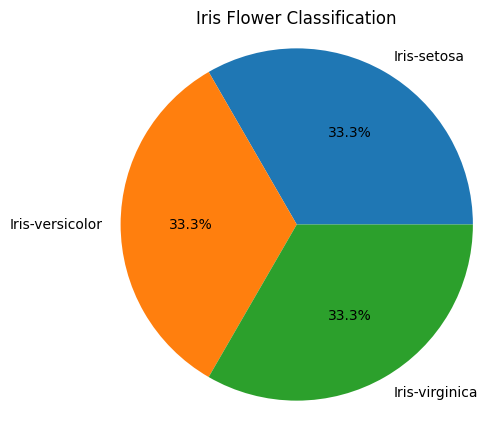

In [94]:
species_counts = df['Species'].value_counts()
plt.figure(figsize=(5, 5))
plt.title('Iris Flower Classification')
plt.pie(species_counts, labels=species_counts.index, autopct='%1.1f%%', startangle=0)
plt.axis('equal')
plt.show()

In [95]:
def barplot(a,b,c):
  plt.figure(figsize=(10, 6))
  sns.barplot(data=df, x=a, y=b)
  plt.title(c)
  return plt.show()

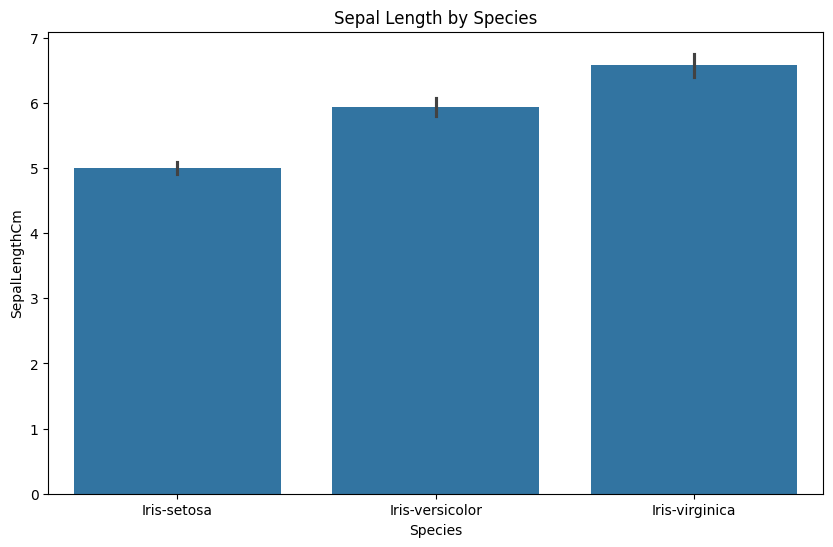

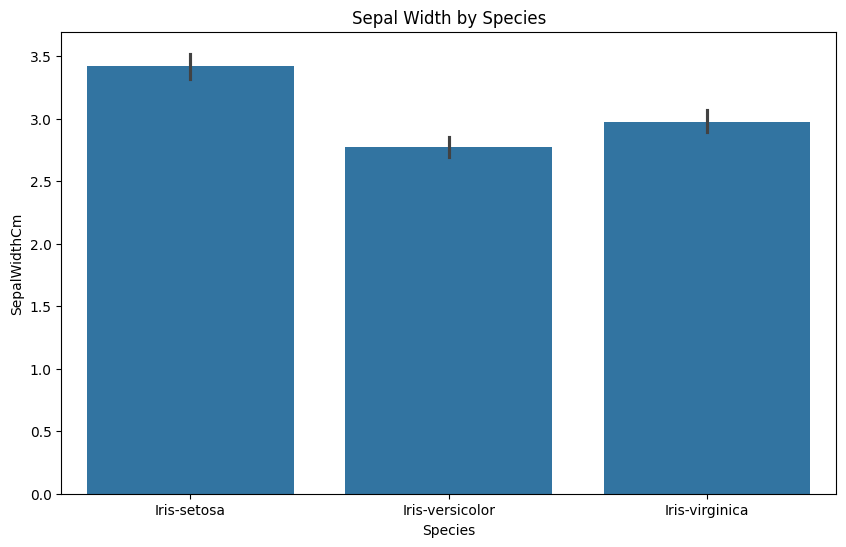

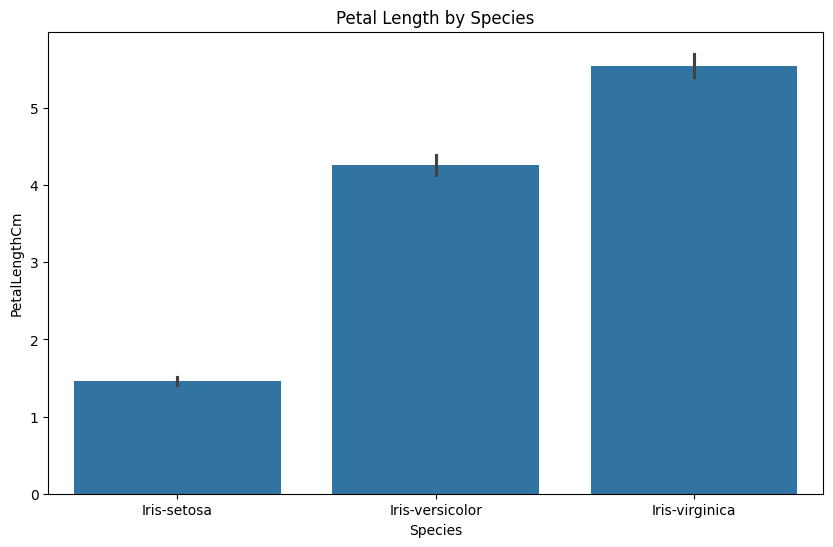

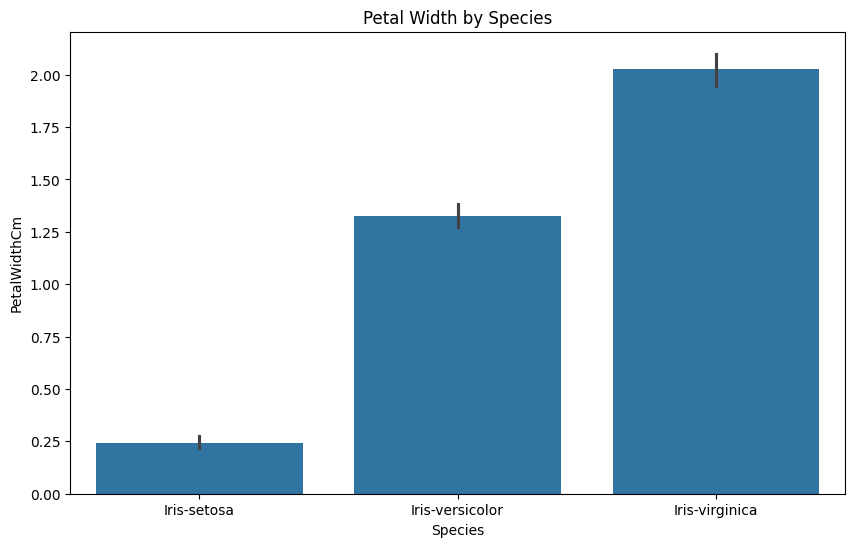

In [96]:
barplot(df['Species'], df['SepalLengthCm'], 'Sepal Length by Species' )
barplot(df['Species'], df['SepalWidthCm'], 'Sepal Width by Species' )
barplot(df['Species'], df['PetalLengthCm'], 'Petal Length by Species' )
barplot(df['Species'], df['PetalWidthCm'], 'Petal Width by Species' )


KNN with k = 1
Train Accuracy: 1.0000
Test Accuracy: 1.0000

KNN with k = 2
Train Accuracy: 0.9833
Test Accuracy: 0.9444

KNN with k = 3
Train Accuracy: 0.9833
Test Accuracy: 0.9556

KNN with k = 4
Train Accuracy: 0.9667
Test Accuracy: 0.9111

KNN with k = 5
Train Accuracy: 0.9833
Test Accuracy: 0.9333

KNN with k = 6
Train Accuracy: 0.9833
Test Accuracy: 0.9222

KNN with k = 7
Train Accuracy: 0.9833
Test Accuracy: 0.9667

KNN with k = 8
Train Accuracy: 0.9833
Test Accuracy: 0.9333

KNN with k = 9
Train Accuracy: 0.9833
Test Accuracy: 0.9333

KNN with k = 10
Train Accuracy: 0.9667
Test Accuracy: 0.9111


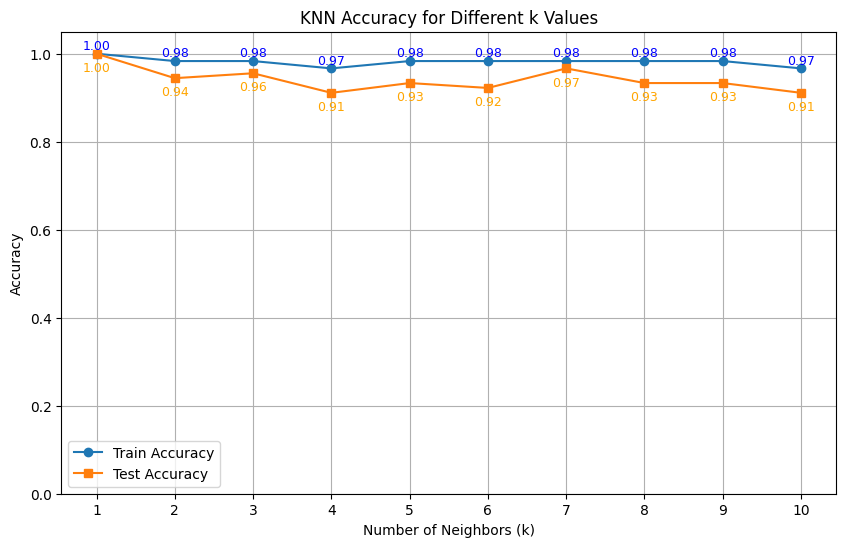

In [97]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report


X = df.drop('Species', axis=1)
y = df['Species']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=52)

train_accuracies = []
test_accuracies = []


for k in range(1, 11):
    print(f"\nKNN with k = {k}")
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    # print("Classification Report:")
    # print(classification_report(y_test, y_test_pred))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), train_accuracies, label='Train Accuracy', marker='o')
plt.plot(range(1, 11), test_accuracies, label='Test Accuracy', marker='s')
for i, (train_acc, test_acc) in enumerate(zip(train_accuracies, test_accuracies), start=1):
    plt.text(i, train_acc + 0.01, f"{train_acc:.2f}", ha='center', color='blue', fontsize=9)
    plt.text(i, test_acc - 0.04, f"{test_acc:.2f}", ha='center', color='orange', fontsize=9)
plt.title('KNN Accuracy for Different k Values')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)
plt.show()


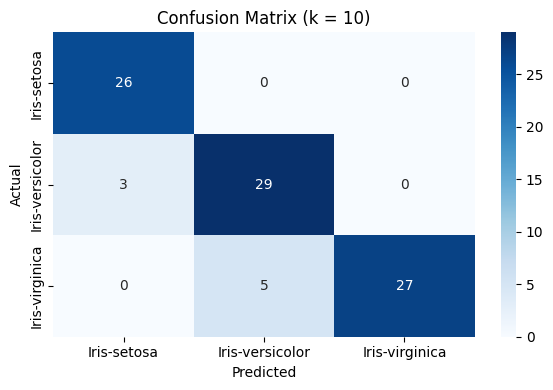

In [100]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.title(f'Confusion Matrix (k = {k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()